In [1]:
import pandas as pd

df = pd.read_csv("IMDB Dataset.csv")

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [6]:
df.shape

(50000, 2)

In [8]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     50000 non-null  str  
 1   sentiment  50000 non-null  str  
dtypes: str(2)
memory usage: 781.4 KB


In [10]:
df.isnull().sum()


review       0
sentiment    0
dtype: int64

In [12]:
df["sentiment"].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [14]:
df.duplicated().sum()

np.int64(418)

In [15]:
df.shape
df.info()
df.isnull().sum()
df["sentiment"].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     50000 non-null  str  
 1   sentiment  50000 non-null  str  
dtypes: str(2)
memory usage: 781.4 KB


sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [20]:
df["review_length"] = df["review"].str.len()
df["review_length"].describe()

count    50000.000000
mean      1309.431020
std        989.728014
min         32.000000
25%        699.000000
50%        970.000000
75%       1590.250000
max      13704.000000
Name: review_length, dtype: float64

In [22]:
df[["review_length", "sentiment"]].groupby("sentiment").mean()

,review_length
sentiment,
negative,1294.06436
positive,1324.79768


In [24]:
import re

def clean_text(text):
    text = re.sub(r"<br\s*/?>", " ", text)
    return text

In [26]:
sample = df["review"].iloc[1]

print("BEFORE:")
print(sample)

print("\nAFTER:")
print(clean_text(sample))

BEFORE:
A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. <br /><br />The actors are extremely well chosen- Michael Sheen not only "has got all the polari" but he has all the voices down pat too! You can truly see the seamless editing guided by the references to Williams' diary entries, not only is it well worth the watching but it is a terrificly written and performed piece. A masterful production about one of the great master's of comedy and his life. <br /><br />The realism really comes home with the little things: the fantasy of the guard which, rather than use the traditional 'dream' techniques remains solid then disappears. It plays on our knowledge and our senses, particularly with the scenes concerning Orton and Halliwell and the sets (particularly of their flat with Halliwell's murals decorating every surface) are terribly well

In [28]:
import re

def clean_text(text):
    # Remove HTML line-break tags
    text = re.sub(r"<br\s*/?>", " ", text)

    # Replace multiple spaces with a single space
    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [30]:
sample = df["review"].iloc[1]

print("BEFORE:")
print(sample)

print("\nAFTER:")
print(clean_text(sample))

BEFORE:
A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. <br /><br />The actors are extremely well chosen- Michael Sheen not only "has got all the polari" but he has all the voices down pat too! You can truly see the seamless editing guided by the references to Williams' diary entries, not only is it well worth the watching but it is a terrificly written and performed piece. A masterful production about one of the great master's of comedy and his life. <br /><br />The realism really comes home with the little things: the fantasy of the guard which, rather than use the traditional 'dream' techniques remains solid then disappears. It plays on our knowledge and our senses, particularly with the scenes concerning Orton and Halliwell and the sets (particularly of their flat with Halliwell's murals decorating every surface) are terribly well

In [34]:
import re

def clean_text(text):
    # Remove HTML tags
    text = re.sub(r"<br\s*/?>", " ", text)

    # Convert text to lowercase
    text = text.lower()

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [38]:
sample = "THIS Movie Was AMAZING!"

print(clean_text(sample))


this movie was amazing!


In [40]:
import re

def clean_text(text):
    # Remove HTML tags
    text = re.sub(r"<br\s*/?>", " ", text)

    # Convert to lowercase
    text = text.lower()

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [42]:
df["clean_review"] = df["review"].apply(clean_text)

In [44]:
df[["review", "clean_review"]].head()

,review,clean_review
0,One of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,a wonderful little production. the filming tec...
2,I thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,basically there's a family where a little boy ...
4,"Petter Mattei's ""Love in the Time of Money"" is...","petter mattei's ""love in the time of money"" is..."


In [46]:
df["clean_review"] = df["review"].apply(clean_text)

In [48]:
df[["review", "clean_review"]].head()

,review,clean_review
0,One of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,a wonderful little production. the filming tec...
2,I thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,basically there's a family where a little boy ...
4,"Petter Mattei's ""Love in the Time of Money"" is...","petter mattei's ""love in the time of money"" is..."


In [50]:
from sklearn.feature_extraction.text import TfidfVectorizer


In [52]:
tfidf = TfidfVectorizer()

In [54]:
df = df.drop_duplicates().reset_index(drop=True)

print(df.shape)

(49582, 4)


In [56]:
X = df["clean_review"]
y = df["sentiment"]

In [58]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [60]:
print("Training reviews:", len(X_train))
print("Testing reviews:", len(X_test))

print("\nTraining labels:")
print(y_train.value_counts())

print("\nTesting labels:")
print(y_test.value_counts())

Training reviews: 39665
Testing reviews: 9917

Training labels:
sentiment
positive    19907
negative    19758
Name: count, dtype: int64

Testing labels:
sentiment
positive    4977
negative    4940
Name: count, dtype: int64


In [62]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=2
)

In [64]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [66]:
print("Training shape:", X_train_tfidf.shape)
print("Testing shape:", X_test_tfidf.shape)

Training shape: (39665, 50000)
Testing shape: (9917, 50000)


In [68]:
print(tfidf.get_feature_names_out()[:30])

['00' '000' '000 000' '000 to' '007' '01' '02' '10' '10 000' '10 10'
 '10 15' '10 and' '10 as' '10 because' '10 bethany' '10 but' '10 for'
 '10 from' '10 if' '10 in' '10 is' '10 it' '10 lines' '10 minutes' '10 of'
 '10 on' '10 or' '10 out' '10 rating' '10 seconds']


In [70]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_tfidf, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use i

In [72]:
y_pred = lr_model.predict(X_test_tfidf)

print(y_pred[:10])

['negative' 'positive' 'positive' 'negative' 'negative' 'positive'
 'negative' 'negative' 'positive' 'negative']


In [74]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9043057376222648


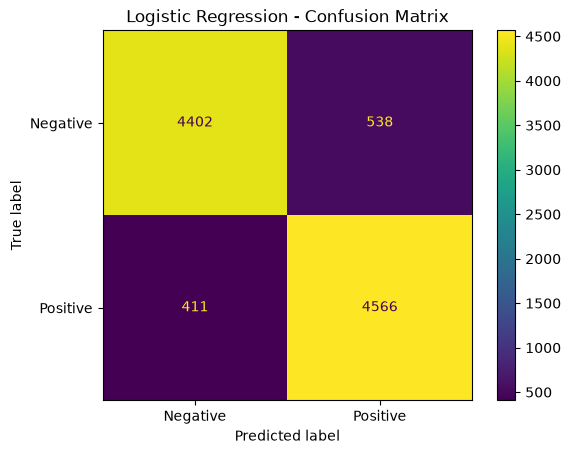

In [76]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels=["negative", "positive"])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
)

disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [78]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.91      0.89      0.90      4940
    positive       0.89      0.92      0.91      4977

    accuracy                           0.90      9917
   macro avg       0.90      0.90      0.90      9917
weighted avg       0.90      0.90      0.90      9917



In [80]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[19758.,19907.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.7 ,-0.69]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[<U8](2,)","['negative','positive']"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 50000)","[[ 5.99,13.33, 2.3 ,..., 0.12, 3.49, 1.31], [ 4.94,10.02, 1.04,..., 2.89, 0.38, 1.26]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 50000)","[[-10.71, -9.99,-11.46,...,-12.54,-11.15,-11.82], [-10.86,-10.24,-11.93,...,-11.28,-12.32,-11.83]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,50000


In [82]:
y_pred_nb = nb_model.predict(X_test_tfidf)

In [84]:
from sklearn.metrics import accuracy_score, classification_report

nb_accuracy = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", nb_accuracy)
print()
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.8829283049309267

              precision    recall  f1-score   support

    negative       0.89      0.88      0.88      4940
    positive       0.88      0.89      0.88      4977

    accuracy                           0.88      9917
   macro avg       0.88      0.88      0.88      9917
weighted avg       0.88      0.88      0.88      9917



In [89]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()

svm_model.fit(X_train_tfidf, y_train)


,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

In [91]:
y_pred_svm = svm_model.predict(X_test_tfidf)

In [93]:
from sklearn.metrics import accuracy_score, classification_report

svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", svm_accuracy)
print()
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.9092467480084703

              precision    recall  f1-score   support

    negative       0.91      0.90      0.91      4940
    positive       0.90      0.92      0.91      4977

    accuracy                           0.91      9917
   macro avg       0.91      0.91      0.91      9917
weighted avg       0.91      0.91      0.91      9917



In [95]:
results = {
    "Logistic Regression": accuracy,
    "Naive Bayes": nb_accuracy,
    "Linear SVM": svm_accuracy
}

for model, score in results.items():
    print(f"{model}: {score:.4f}")

Logistic Regression: 0.9043
Naive Bayes: 0.8829
Linear SVM: 0.9092


In [97]:
tfidf_rf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2
)

X_train_rf = tfidf_rf.fit_transform(X_train)
X_test_rf = tfidf_rf.transform(X_test)

In [99]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_rf, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [101]:
y_pred_rf = rf_model.predict(X_test_rf)

In [103]:
from sklearn.metrics import accuracy_score, classification_report

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)
print()
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.8546939598668952

              precision    recall  f1-score   support

    negative       0.86      0.85      0.85      4940
    positive       0.85      0.86      0.86      4977

    accuracy                           0.85      9917
   macro avg       0.85      0.85      0.85      9917
weighted avg       0.85      0.85      0.85      9917



In [105]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_rf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2
)

X_train_rf = tfidf_rf.fit_transform(X_train)
X_test_rf = tfidf_rf.transform(X_test)

print("Training shape:", X_train_rf.shape)
print("Testing shape:", X_test_rf.shape)

Training shape: (39665, 5000)
Testing shape: (9917, 5000)


In [107]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_rf, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [111]:
y_pred_rf = rf_model.predict(X_test_rf)

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)
print()
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.8546939598668952

              precision    recall  f1-score   support

    negative       0.86      0.85      0.85      4940
    positive       0.85      0.86      0.86      4977

    accuracy                           0.85      9917
   macro avg       0.85      0.85      0.85      9917
weighted avg       0.85      0.85      0.85      9917



In [113]:
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("Training:", len(X_train_sub))
print("Validation:", len(X_val))

Training: 31732
Validation: 7933


In [115]:
tfidf_tune = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=2
)

X_train_sub_tfidf = tfidf_tune.fit_transform(X_train_sub)
X_val_tfidf = tfidf_tune.transform(X_val)

print("Training TF-IDF:", X_train_sub_tfidf.shape)
print("Validation TF-IDF:", X_val_tfidf.shape)

Training TF-IDF: (31732, 50000)
Validation TF-IDF: (7933, 50000)


In [117]:
print("Training:", len(X_train_sub))
print("Validation:", len(X_val))

Training: 31732
Validation: 7933


In [119]:
print("Training TF-IDF:", X_train_sub_tfidf.shape)
print("Validation TF-IDF:", X_val_tfidf.shape)

Training TF-IDF: (31732, 50000)
Validation TF-IDF: (7933, 50000)


In [121]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score

C_values = [0.25, 0.5, 1.0, 1.5, 2.0]

svm_results = []

for c in C_values:
    model = LinearSVC(C=c, random_state=42, max_iter=2000)
    
    model.fit(X_train_sub_tfidf, y_train_sub)
    
    val_pred = model.predict(X_val_tfidf)
    
    accuracy = accuracy_score(y_val, val_pred)
    f1 = f1_score(y_val, val_pred, pos_label="positive")
    
    svm_results.append((c, accuracy, f1))
    
    print(f"C={c:<4} | Accuracy={accuracy:.4f} | F1={f1:.4f}")

C=0.25 | Accuracy=0.9066 | F1=0.9081
C=0.5  | Accuracy=0.9090 | F1=0.9103
C=1.0  | Accuracy=0.9067 | F1=0.9081
C=1.5  | Accuracy=0.9058 | F1=0.9072
C=2.0  | Accuracy=0.9044 | F1=0.9058


In [123]:
final_svm = LinearSVC(
    C=0.5,
    random_state=42,
    max_iter=2000
)

final_svm.fit(X_train_tfidf, y_train)

final_svm_pred = final_svm.predict(X_test_tfidf)

In [125]:
from sklearn.metrics import accuracy_score, classification_report

final_svm_accuracy = accuracy_score(y_test, final_svm_pred)

print("Final SVM Accuracy:", final_svm_accuracy)
print()
print(classification_report(y_test, final_svm_pred))

Final SVM Accuracy: 0.9106584652616718

              precision    recall  f1-score   support

    negative       0.92      0.90      0.91      4940
    positive       0.90      0.92      0.91      4977

    accuracy                           0.91      9917
   macro avg       0.91      0.91      0.91      9917
weighted avg       0.91      0.91      0.91      9917



In [127]:
error_df = pd.DataFrame({
    "review": X_test.values,
    "actual": y_test.values,
    "predicted": final_svm_pred
})

errors = error_df[
    error_df["actual"] != error_df["predicted"]
].copy()

print("Total test reviews:", len(error_df))
print("Incorrect predictions:", len(errors))
print("Error rate:", len(errors) / len(error_df))

Total test reviews: 9917
Incorrect predictions: 886
Error rate: 0.08934153473832812


In [129]:
errors.head(10)

,review,actual,predicted
15,"this isn't exactly a great film, but i admire ...",positive,negative
24,despite being a huge fan of fred astaire and g...,negative,positive
32,"i know that full moon, or any other film studi...",negative,positive
35,"well, well....roeg touched a bit of a nerve th...",positive,negative
43,"ok, let me again admit that i haven't seen any...",negative,positive
45,"i'm not here to tell you ""armored"" is kubricki...",positive,negative
51,"this movie probably had a $750 budget, and sti...",positive,negative
78,i was excited to hear that someone had made a ...,negative,positive
79,"using tons of stock footage, not only from tra...",negative,positive
106,"""saving grace"" is never riotously funny, but i...",positive,negative


In [131]:
error_counts = pd.crosstab(
    errors["actual"],
    errors["predicted"]
)

print(error_counts)

predicted  negative  positive
actual                       
negative          0       484
positive        402         0


In [133]:
print("Negative → Positive:",
      len(errors[(errors["actual"] == "negative") &
                 (errors["predicted"] == "positive")]))

print("Positive → Negative:",
      len(errors[(errors["actual"] == "positive") &
                 (errors["predicted"] == "negative")]))

Negative → Positive: 484
Positive → Negative: 402


In [135]:
errors["review_length"] = errors["review"].str.len()

correct = error_df[
    error_df["actual"] == error_df["predicted"]
].copy()

correct["review_length"] = correct["review"].str.len()

print("Average length of incorrect reviews:",
      errors["review_length"].mean())

print("Average length of correct reviews:",
      correct["review_length"].mean())

Average length of incorrect reviews: 1288.8713318284424
Average length of correct reviews: 1283.942974199978


In [137]:
print("\nMedian length of incorrect reviews:",
      errors["review_length"].median())

print("Median length of correct reviews:",
      correct["review_length"].median())


Median length of incorrect reviews: 969.0
Median length of correct reviews: 946.0


In [139]:
decision_scores = final_svm.decision_function(X_test_tfidf)

error_df["decision_score"] = decision_scores

In [141]:
error_df["confidence"] = error_df["decision_score"].abs()

print("Average decision score magnitude - correct:",
      error_df[error_df["actual"] == error_df["predicted"]]["confidence"].mean())

print("Average decision score magnitude - incorrect:",
      error_df[error_df["actual"] != error_df["predicted"]]["confidence"].mean())

Average decision score magnitude - correct: 1.005509004500235
Average decision score magnitude - incorrect: 0.3066698170349255


In [143]:
most_uncertain = error_df.sort_values("confidence").head(10)

most_uncertain[["review", "actual", "predicted", "decision_score"]]

,review,actual,predicted,decision_score
4444,"you may like tim burton's fantasies, but not i...",negative,positive,0.000200
7557,"a chicago couple, dillon and dougherty, are fa...",negative,positive,0.000457
9161,my brother tom aspect ratio: 1.85:1 sound form...,negative,negative,-0.000511
3869,i must say that i really had no idea that i wa...,positive,positive,0.000770
1604,"this is actually a groovy-neat little flick, m...",positive,positive,0.000863
6827,what happens when someone has so much social a...,positive,negative,-0.001053
6497,why has ramón(carlos fuentes)brought his five ...,positive,negative,-0.001101
4077,"this adaptation, like 1949's *the heiress*, is...",negative,positive,0.001130
7984,thanks to this fungal film i do not want my ma...,positive,positive,0.001572
7122,this movie was marketed extremely well. when i...,positive,negative,-0.001680


In [144]:
import joblib

joblib.dump(final_svm, "sentiment_svm.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!
